## Project: Employee Mental Health
Happy Hearts, Profitable Charts!

**Project Appendix**
- Data Cleaning
- Data Processing
- Exploratory Data Analysis

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import numpy as np

# Suppress SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [81]:
# Define the file path
file_path = r"C:\Users\rgala\Desktop\ESMT\OGA\Assignment\Impact_of_Remote_Work_on_Mental_Health.csv"

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame to verify
df.head()


,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [83]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Job_Role', 'Industry',
       'Years_of_Experience', 'Work_Location', 'Hours_Worked_Per_Week',
       'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating',
       'Stress_Level', 'Mental_Health_Condition',
       'Access_to_Mental_Health_Resources', 'Productivity_Change',
       'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work',
       'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality',
       'Region'],
      dtype='object')

## Data Cleaning

In [86]:
df.shape

(5000, 20)

In [88]:
df.duplicated().sum()


0

In [90]:
df.isnull().sum()


Employee_ID                             0
Age                                     0
Gender                                  0
Job_Role                                0
Industry                                0
Years_of_Experience                     0
Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
Region                                  0
dtype: int64

In [92]:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

Employee_ID                           0.00
Age                                   0.00
Gender                                0.00
Job_Role                              0.00
Industry                              0.00
Years_of_Experience                   0.00
Work_Location                         0.00
Hours_Worked_Per_Week                 0.00
Number_of_Virtual_Meetings            0.00
Work_Life_Balance_Rating              0.00
Stress_Level                          0.00
Mental_Health_Condition              23.92
Access_to_Mental_Health_Resources     0.00
Productivity_Change                   0.00
Social_Isolation_Rating               0.00
Satisfaction_with_Remote_Work         0.00
Company_Support_for_Remote_Work       0.00
Physical_Activity                    32.58
Sleep_Quality                         0.00
Region                                0.00
dtype: float64


Rows with missing values are being dropped because the affected columns, Mental_Health_Condition and Physical_Activity, have a significant proportion of missing data (23.92% and 32.58%, respectively), and imputing these values risks introducing bias or inaccuracies in the analysis, while retaining rows with complete data ensures the integrity of the insights

In [120]:
# Drop rows with any missing values
df_cleaned = df.dropna()


In [122]:
df_cleaned.shape

(2577, 21)

In [124]:
df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 4997
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Employee_ID                        2577 non-null   object
 1   Age                                2577 non-null   int64 
 2   Gender                             2577 non-null   object
 3   Job_Role                           2577 non-null   object
 4   Industry                           2577 non-null   object
 5   Years_of_Experience                2577 non-null   int64 
 6   Work_Location                      2577 non-null   object
 7   Hours_Worked_Per_Week              2577 non-null   int64 
 8   Number_of_Virtual_Meetings         2577 non-null   int64 
 9   Work_Life_Balance_Rating           2577 non-null   int64 
 10  Stress_Level                       2577 non-null   object
 11  Mental_Health_Condition            2577 non-null   object
 12  Access_to_M

In [101]:
df_cleaned.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
6,EMP0007,31,Prefer not to say,Sales,IT,24,Remote,51,7,3,Low,Anxiety,Yes,Decrease,5,Neutral,3,Daily,Poor,Asia
9,EMP0010,30,Female,HR,IT,28,Hybrid,57,6,1,Low,Depression,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America
12,EMP0013,40,Female,Marketing,Consulting,1,Remote,21,7,2,High,Depression,Yes,Decrease,2,Neutral,1,Weekly,Good,Europe


## Data Preparation


In [104]:
df_cleaned.describe()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,2577.000000,2577.000000,2577.000000,2577.000000,2577.000000,2577.000000,2577.000000
mean,40.910749,17.760574,39.634459,7.446643,2.985642,3.004269,3.001552
std,11.258183,9.981957,11.886100,4.592684,1.413454,1.388304,1.394866
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,3.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,39.000000,7.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,11.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


In [106]:
# Drop the column Employee_ID
df_cleaned = df_cleaned.drop(columns=['Employee_ID'], axis=1)

df_cleaned.head()


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
6,31,Prefer not to say,Sales,IT,24,Remote,51,7,3,Low,Anxiety,Yes,Decrease,5,Neutral,3,Daily,Poor,Asia
9,30,Female,HR,IT,28,Hybrid,57,6,1,Low,Depression,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America
12,40,Female,Marketing,Consulting,1,Remote,21,7,2,High,Depression,Yes,Decrease,2,Neutral,1,Weekly,Good,Europe


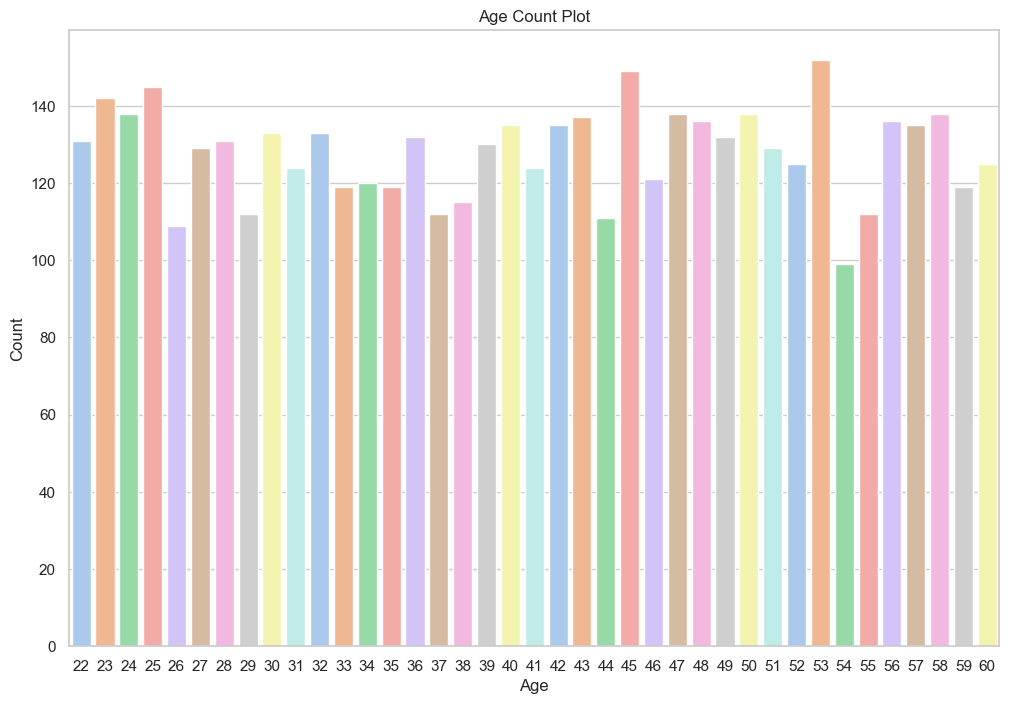

In [108]:
# Set the figure size
plt.figure(figsize=(12, 8))  # Adjust width and height as needed

# Create the count plot for 'Age'
sns.countplot(data=df, x='Age', palette='pastel').set(title='Age Count Plot')

# Customize labels
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Show the plot
plt.show()

We have data on employees with ages between 22 and 60 years old. No age group within these boundaries is underrepresented, that's good

**Let's check what genders do we have.**




[Text(0.5, 1.0, "Dependence of experience on the employee's age"),
 Text(0.5, 0, 'Age (years)'),
 Text(0, 0.5, 'Experience (years)')]

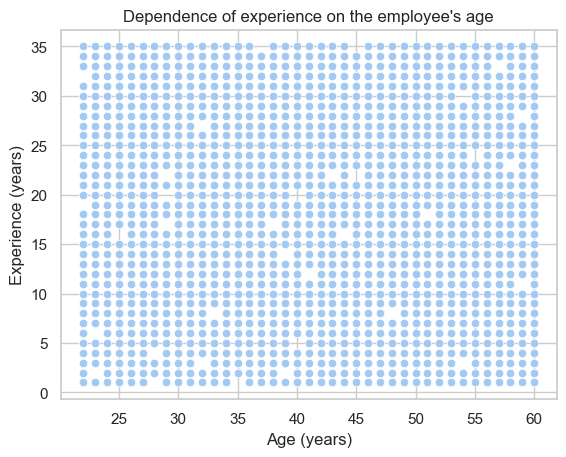

In [131]:
sns.scatterplot(df, x='Age', y='Years_of_Experience').set(title='Dependence of experience on the employee\'s age', xlabel='Age (years)', ylabel='Experience (years)')

We observe no correlation between age and experience.
That's kinda strange, how 25 years old employee could gain 35 years of experience? Probably Years_of_Experience is not trustworthy.
We see two ways to fix this: either to discard evidently flawed entries (eg. where age + 15 years is less than experience), or to drop experience column entierly.

In [134]:
# Drop the column Employee_ID
df_cleaned = df_cleaned.drop(columns=['Years_of_Experience'], axis=1)

df_cleaned.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region,Job_Group
0,EMP0001,32,Non-binary,HR,Healthcare,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe,Group 1
1,EMP0002,40,Female,Data Scientist,IT,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia,Group 2
6,EMP0007,31,Prefer not to say,Sales,IT,Remote,51,7,3,Low,Anxiety,Yes,Decrease,5,Neutral,3,Daily,Poor,Asia,Group 2
9,EMP0010,30,Female,HR,IT,Hybrid,57,6,1,Low,Depression,Yes,Decrease,2,Neutral,1,Weekly,Poor,North America,Group 1
12,EMP0013,40,Female,Marketing,Consulting,Remote,21,7,2,High,Depression,Yes,Decrease,2,Neutral,1,Weekly,Good,Europe,Group 1


## Exploratory Data Analysis

Does the type of work location affect job satisfaction?


Contingency Table:
Satisfaction_with_Remote_Work  Neutral  Satisfied  Unsatisfied
Work_Location                                                 
Hybrid                             263        292          281
Onsite                             259        315          274
Remote                             315        278          300


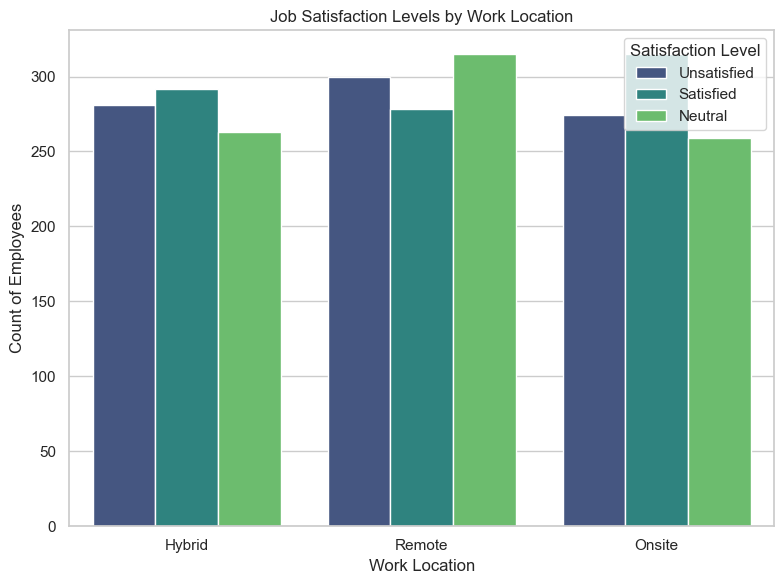

In [138]:
from scipy.stats import chi2_contingency

# Contingency table
contingency_table = pd.crosstab(df_cleaned['Work_Location'], df_cleaned['Satisfaction_with_Remote_Work'])

# Display contingency table
print("Contingency Table:")
print(contingency_table)

# Visualization: Grouped Bar Chart
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='Work_Location', hue='Satisfaction_with_Remote_Work', palette='viridis')
plt.title("Job Satisfaction Levels by Work Location")
plt.xlabel("Work Location")
plt.ylabel("Count of Employees")
plt.legend(title="Satisfaction Level")
plt.tight_layout()
plt.show()


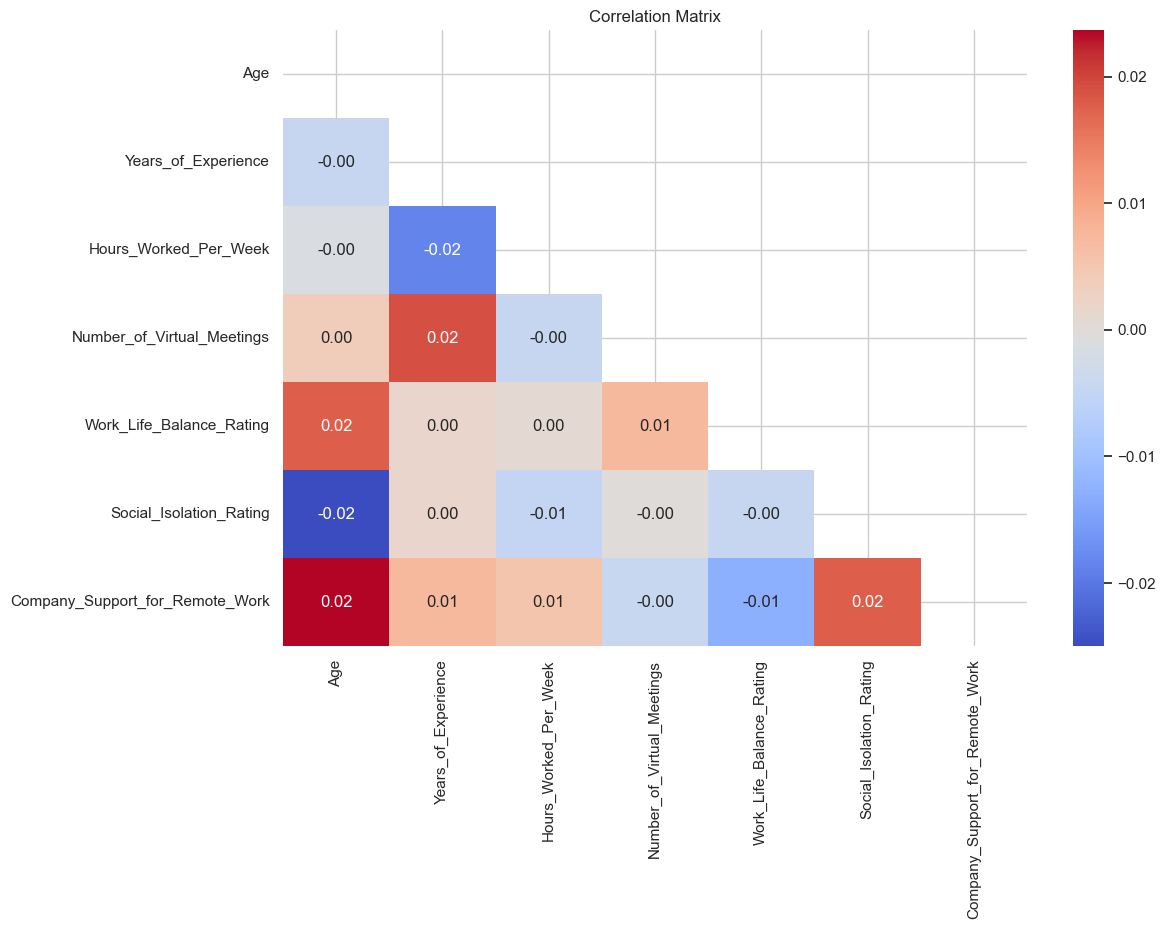

In [140]:
# Correlation matrix heatmap with only numeric columns
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])  # Select only numeric columns
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=np.triu(correlation_matrix))
plt.title('Correlation Matrix')
plt.show()

The correlation matrix indicates that the relationships between the variables are extremely weak, with all correlation coefficients close to 0 (ranging between -0.02 and 0.02). This suggests an absence of meaningful linear relationships among the variables in the dataset.

This lack of correlation, combined with the uniformity of values and a nearly random appearance of the data, could indicate that the data is synthetic.

**What is the average work-life balance rating by job role?**

In [144]:
df.groupby('Job_Role')['Work_Life_Balance_Rating'].mean()


Job_Role
Data Scientist       3.007184
Designer             2.966805
HR                   2.930168
Marketing            2.945827
Project Manager      2.960705
Sales                3.043656
Software Engineer    3.033755
Name: Work_Life_Balance_Rating, dtype: float64

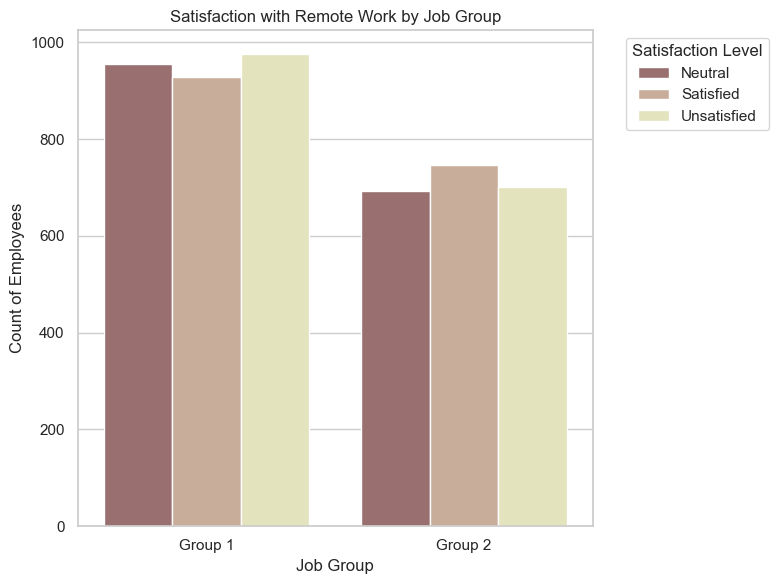

In [146]:
# Define the groups
group_1 = ['HR', 'Designer', 'Project Manager', 'Marketing']
group_2 = ['Data Scientist', 'Sales', 'Software Engineer']

# Add a new column for grouping
df['Job_Group'] = df['Job_Role'].apply(lambda x: 'Group 1' if x in group_1 else 'Group 2')

# Group by Job_Group and Satisfaction_with_Remote_Work
grouped_data = df.groupby(['Job_Group', 'Satisfaction_with_Remote_Work']).size().reset_index(name='Count')

# Plot grouped bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Job_Group', y='Count', hue='Satisfaction_with_Remote_Work', data=grouped_data, palette='pink')
plt.title('Satisfaction with Remote Work by Job Group')
plt.xlabel('Job Group')
plt.ylabel('Count of Employees')
plt.legend(title='Satisfaction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Any specific industry, has more mental health issues?**

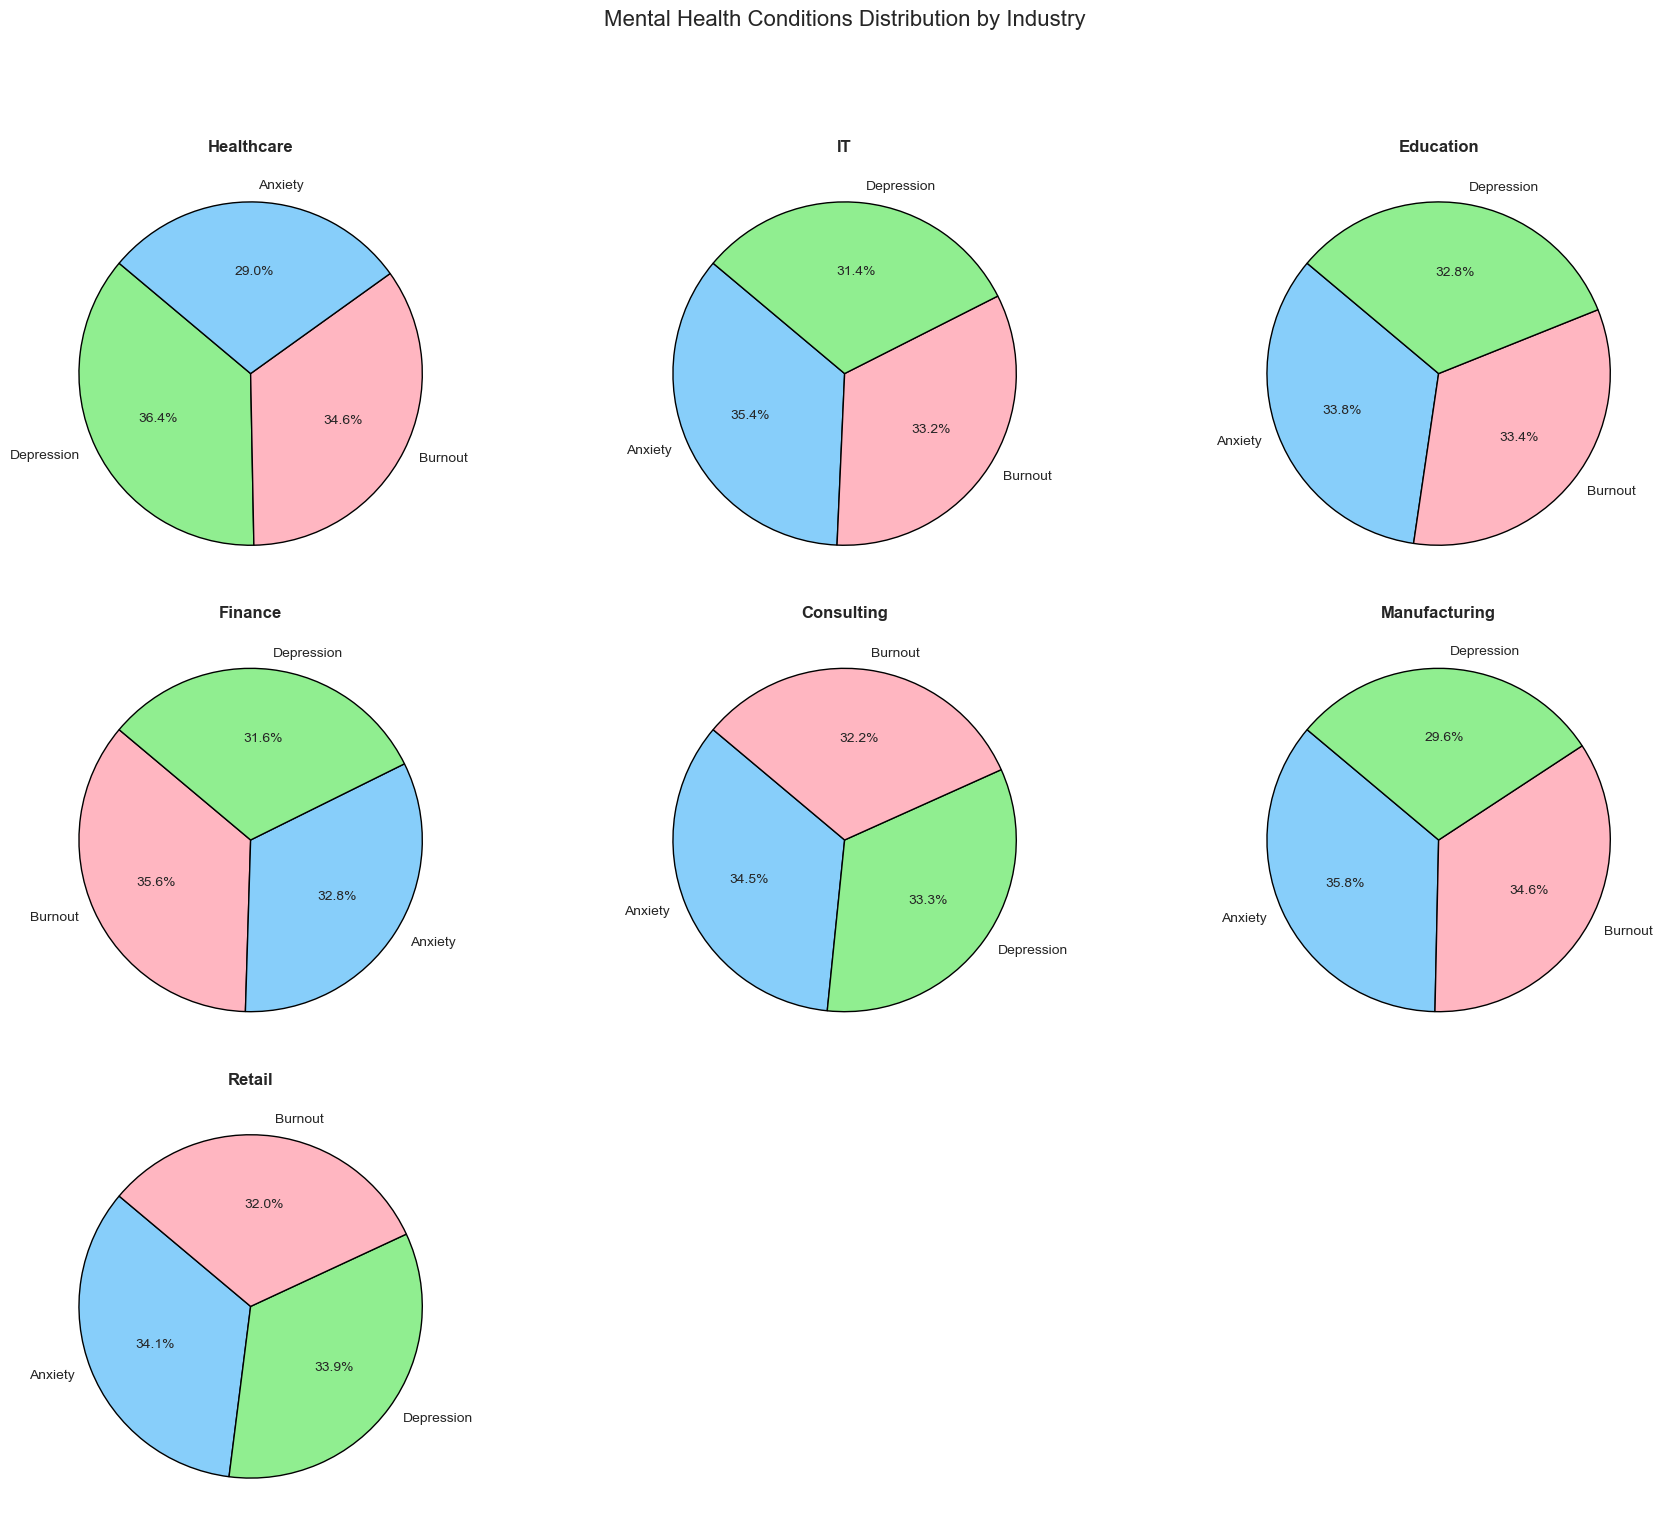

In [149]:
# Step 1: Create a list of all unique industries
industries = df['Industry'].unique()

# Step 2: Set up the number of rows and columns for subplots
num_industries = len(industries)
rows = (num_industries // 3) + (num_industries % 3 > 0)  # Arrange 3 charts per row

# Step 3: Create the grid of pie charts
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))  # Adjust figure size dynamically
fig.suptitle('Mental Health Conditions Distribution by Industry', fontsize=16, y=1.02)

# Flatten axes for easy iteration (handles cases with fewer than 3 charts per row)
axes = axes.flatten()

# Define a consistent color mapping for mental health conditions
color_mapping = {
    'Burnout': '#FFB6C1',  # LightPink
    'Anxiety': '#87CEFA',  # LightBlue
    'Depression': '#90EE90',  # LightGreen
    'Other': '#FFD700'  # Gold
}

# Step 4: Loop through each industry and create a pie chart
for i, industry in enumerate(industries):
    # Filter data for the specific industry
    industry_data = df[df['Industry'] == industry]['Mental_Health_Condition'].value_counts()
    
    # Ensure colors are mapped consistently
    colors = [color_mapping.get(condition, '#D3D3D3') for condition in industry_data.index]  # Default to LightGray for unknown conditions
    
    # Plot the pie chart
    wedges, texts, autotexts = axes[i].pie(
        industry_data, 
        labels=industry_data.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        wedgeprops={'edgecolor': 'black'}
    )
    # Set the title in bold
    axes[i].set_title(f'{industry}', fontsize=12, fontweight='bold')
    
    # Adjust font size for better readability
    for t in texts + autotexts:
        t.set_fontsize(10)

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


**What is the most frequent Mental Health condition reported?**

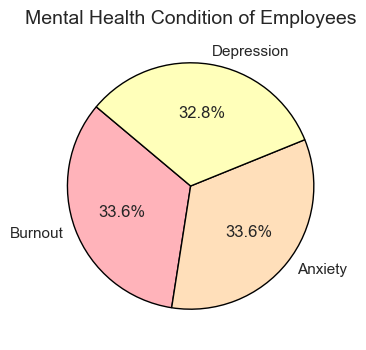

In [152]:
# Count the values for Mental_Health_Condition
mental_health_counts = df['Mental_Health_Condition'].value_counts()

# Define pastel colors
colors = ['#ffb3ba', '#ffdfba', '#ffffba', '#baffc9', '#bae1ff']

# Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(mental_health_counts, labels=mental_health_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})

# Add title
plt.title('Mental Health Condition of Employees', fontsize=14)

# Display the chart
plt.show()

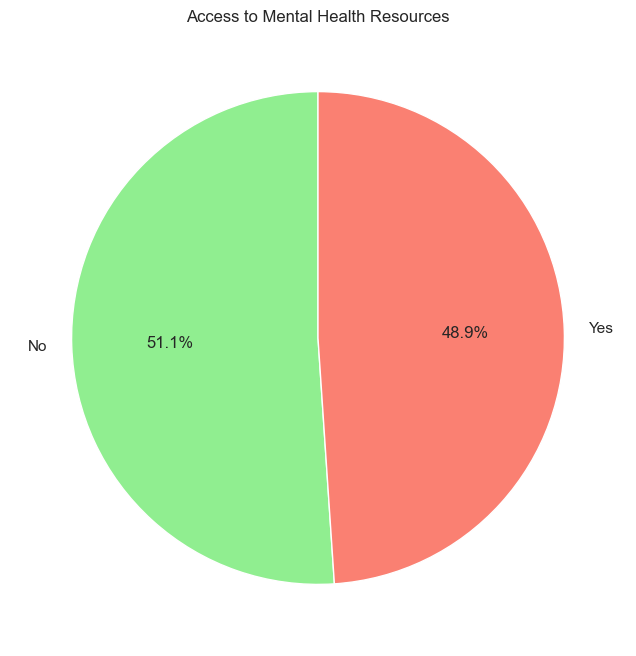

In [154]:
# Pie chart for Access to Mental Health Resources
plt.figure(figsize=(8, 8))
df['Access_to_Mental_Health_Resources'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'salmon'])
plt.title('Access to Mental Health Resources')
plt.ylabel('')
plt.show()

C:\Users\rgala\AppData\Local\Temp\ipykernel_4876\2795809021.py:7: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


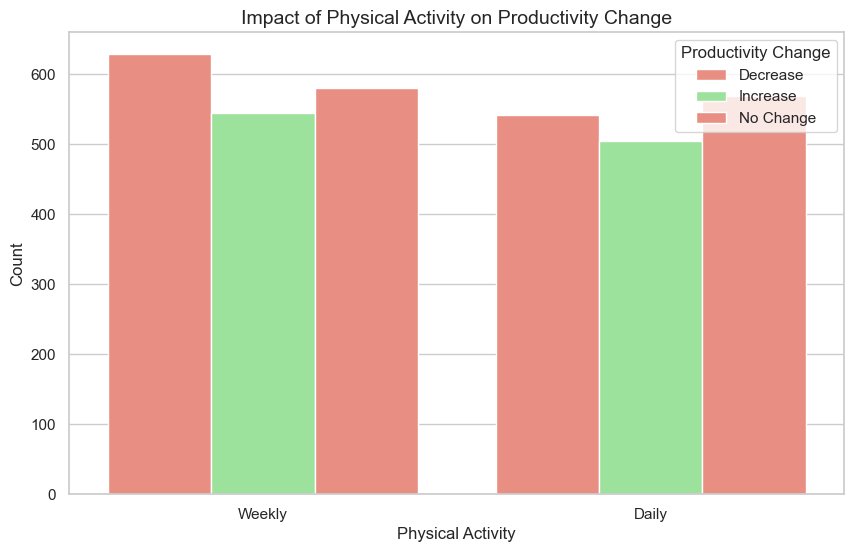

In [156]:

# Set seaborn style and color palette
sns.set(style="whitegrid", palette="pastel")
colors = ['salmon', 'lightgreen']  # Salmon for 'Decrease', Light Green for 'Increase'

# Create a countplot for Physical Activity vs Productivity Change
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Physical_Activity',
    hue='Productivity_Change',
    palette=colors
)

# Add titles and axis labels
plt.title('Impact of Physical Activity on Productivity Change', fontsize=14)
plt.xlabel('Physical Activity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Productivity Change')

# Show the plot
plt.show()


## Strategic Insights

**Should we invest in our employees’ prioritizing their Sleep**


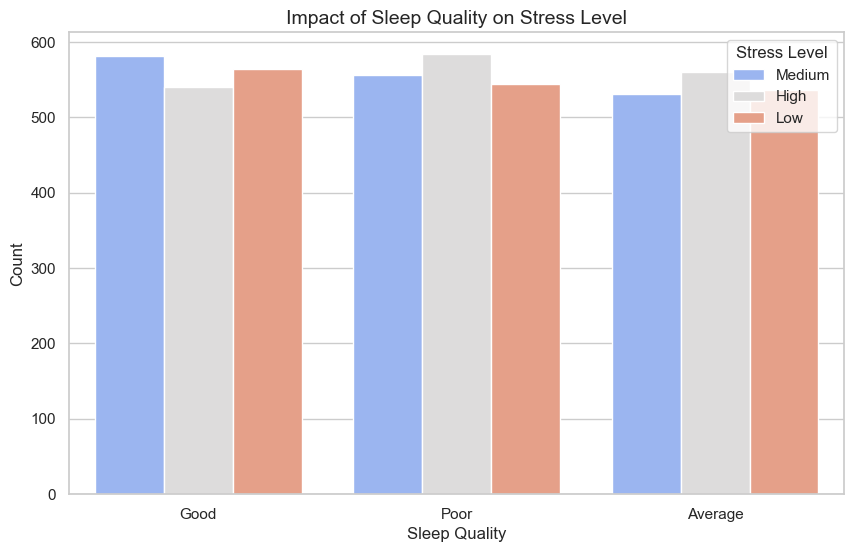

In [160]:
# Set style
sns.set(style="whitegrid", palette="muted")

# Step 1: Count Plot (Grouped Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sleep_Quality', hue='Stress_Level', palette='coolwarm')
plt.title('Impact of Sleep Quality on Stress Level', fontsize=14)
plt.xlabel('Sleep Quality', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Stress Level')
plt.show()


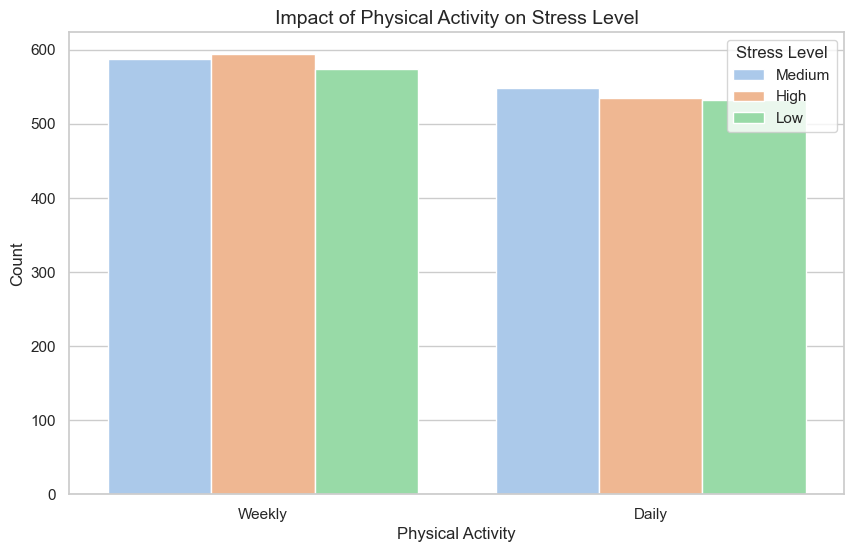

In [162]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Physical_Activity', hue='Stress_Level', palette='pastel')
plt.title('Impact of Physical Activity on Stress Level', fontsize=14)
plt.xlabel('Physical Activity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Stress Level')
plt.show()

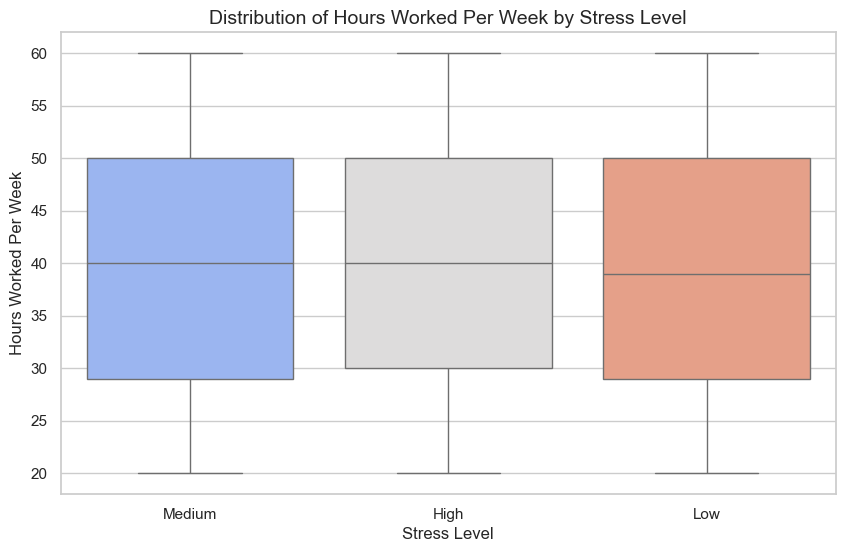

In [164]:
# Set seaborn style
sns.set(style="whitegrid", palette="muted")

# Step 1: Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Stress_Level', y='Hours_Worked_Per_Week', palette='coolwarm')
plt.title('Distribution of Hours Worked Per Week by Stress Level', fontsize=14)
plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('Hours Worked Per Week', fontsize=12)
plt.show()


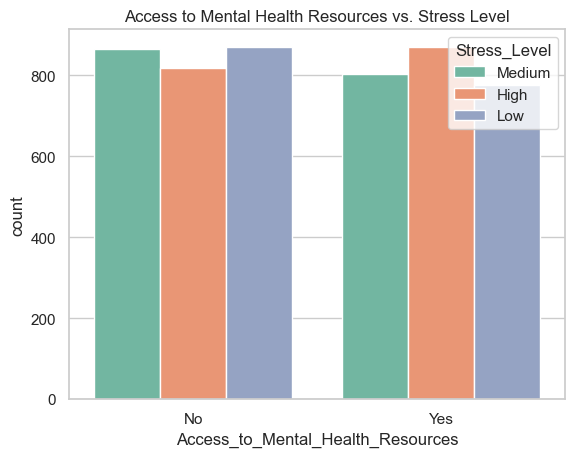

In [165]:
sns.countplot(data=df, x='Access_to_Mental_Health_Resources', hue='Stress_Level', palette='Set2')
plt.title('Access to Mental Health Resources vs. Stress Level')
plt.show()


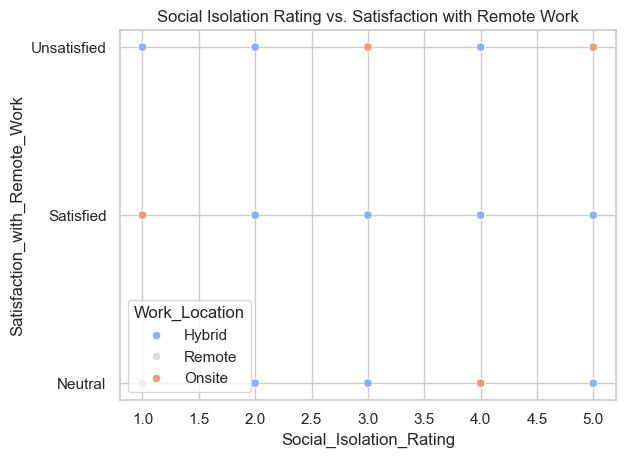

In [167]:
sns.scatterplot(data=df, x='Social_Isolation_Rating', y='Satisfaction_with_Remote_Work', hue='Work_Location', palette='coolwarm')
plt.title('Social Isolation Rating vs. Satisfaction with Remote Work')
plt.show()


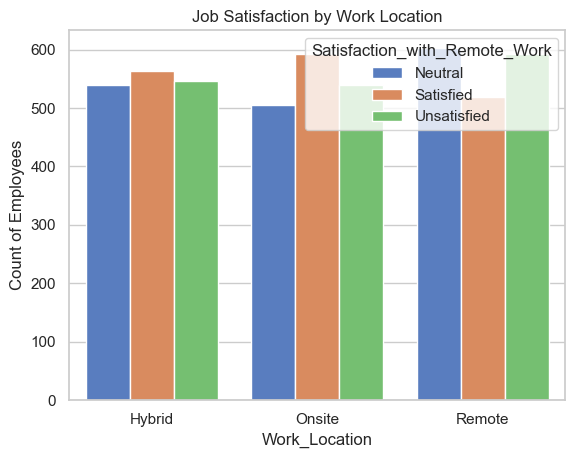

In [169]:
satisfaction_counts = df.groupby(['Work_Location', 'Satisfaction_with_Remote_Work']).size().reset_index(name='Count')
sns.barplot(x='Work_Location', y='Count', hue='Satisfaction_with_Remote_Work', data=satisfaction_counts)
plt.title("Job Satisfaction by Work Location")
plt.ylabel("Count of Employees")
plt.show()


## Thankyou